### 🧠 What is Self-Reflection in RAG?
Self-reflection = LLM evaluates its own output:
“Is this clear, complete, and accurate?”

#### Self-Reflection in RAG using LangGraph, we’ll design a workflow where the agent:

1. Generates an initial answer using retrieved context
2. Reflects on that answer with a dedicated self-critic LLM step
3. If unsatisfied, it can revise the query, retrieve again, or regenerate the answer

In [2]:
import os
from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_classic.vectorstores import FAISS

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model(model = "openai/gpt-oss-120b", model_provider = "groq")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.1'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B162787390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B162787D90>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
## 1. Prepare Vectorstore
docs = TextLoader("sample_docs.txt", encoding = "utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50)

chunks = splitter.split_documents(docs)

## Create embeddings
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(chunks, embeddings)

retriever = vectorstore.as_retriever()
retriever

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001B162AC4980>, search_kwargs={})

In [4]:
## 2. State Definition
class RAGReflectionState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0

In [5]:
## 3. Nodes

# a. Retrieve
def retrieve_docs(state: RAGReflectionState) -> RAGReflectionState:
    docs = retriever.invoke(state.question)
    
    return state.model_copy(update = {"retrieved_docs": docs})

# b. Generate Answer
def generate_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    answer = llm.invoke(prompt).content.strip()

    ## incrementing the attempts and updating the answer
    return state.model_copy(update={"answer": answer, "attempts": state.attempts + 1})

# c. Self-Reflection
def reflect_on_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    prompt = f"""
Reflect on the following answer to see if it fully addresses the question. 
State YES if it is complete and correct, or NO with an explanation.

Question: {state.question}

Answer: {state.answer}

Respond like:
Reflection: YES or NO
Explanation: ...
"""
    result = llm.invoke(prompt).content
    is_ok = "reflection: yes" in result.lower()

    return state.model_copy(update={"reflection": result, "revised": not is_ok})

# d. Finalizer
def finalize(state: RAGReflectionState) -> RAGReflectionState:
    return state

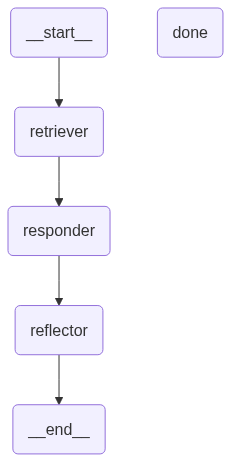

In [6]:
## 4. LangGraph DAG
builder = StateGraph(RAGReflectionState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("done", finalize)

builder.set_entry_point("retriever")

builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")
builder.add_conditional_edges(
    "reflector",
    lambda s: "done" if not s.revised or s.attempts >= 2 else "retriever"
)

builder.add_edge("done", END)

## Compile and view the graph
graph = builder.compile()
graph

In [7]:
## 5. Run the Agent
if __name__ == "__main__":
    user_query = "What are the transformer variants in production deployments?"
    
    init_state = RAGReflectionState(question=user_query)
    result = graph.invoke(init_state)

    print("\n🧠 Final Answer:\n", result["answer"])
    print("\n🔁 Reflection Log:\n", result["reflection"])
    print("🔄 Total Attempts:", result["attempts"])


🧠 Final Answer:
 **Transformer variants that are commonly found in production‑grade systems**

| Variant | Core Idea / Improvement | Typical Production Use‑Cases | Notable Deployments |
|---------|------------------------|------------------------------|---------------------|
| **BERT** (Bidirectional Encoder Representations from Transformers) | Deep bidirectional encoder, pre‑trained on masked‑language‑model and next‑sentence‑prediction tasks. | Question answering, semantic search, document classification, NLU for chatbots. | Google Search, Microsoft Azure Cognitive Search, many internal enterprise NLP pipelines. |
| **RoBERTa** (Robustly Optimized BERT Pretraining Approach) | Removes next‑sentence prediction, trains longer on larger batches and more data. | Same tasks as BERT but with higher accuracy when compute is available. | Facebook AI services, Hugging Face “roberta‑base”/“roberta‑large” APIs. |
| **DistilBERT** | 40 % fewer parameters, 60 % faster inference, retains ~97 % of B